In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
daily_returns = pd.read_csv(
    "daily_returns.csv",
    index_col=0,
    parse_dates=True
)

risk_return = pd.read_csv(
    "risk_return_summary.csv",
    index_col=0
)

annualized_covariance = pd.read_csv(
    "annualized_covariance_matrix.csv",
    index_col=0
)

In [4]:
expected_returns = (
    risk_return["Annualized Return (%)"].values / 100
)

cov_matrix = annualized_covariance.values

n_assets = len(expected_returns)

In [5]:
print("Number of assets:", n_assets)

Number of assets: 20


In [6]:
risk_free_rate = 0.06

In [7]:
def portfolio_statistics(weights, expected_returns, cov_matrix, risk_free_rate=0.06):
    
    portfolio_return = np.dot(weights, expected_returns)
    
    portfolio_variance = (
        weights.T @ cov_matrix @ weights
    )
    
    portfolio_volatility = np.sqrt(portfolio_variance)
    
    sharpe_ratio = (
        portfolio_return - risk_free_rate
    ) / portfolio_volatility
    
    return portfolio_return, portfolio_volatility, sharpe_ratio

In [8]:
equal_weights = np.ones(n_assets) / n_assets

In [9]:
ew_return, ew_volatility, ew_sharpe = portfolio_statistics(
    equal_weights,
    expected_returns,
    cov_matrix,
    risk_free_rate
)

print("Equal-Weight Portfolio")
print("----------------------")
print("Return:", ew_return * 100, "%")
print("Volatility:", ew_volatility * 100, "%")
print("Sharpe Ratio:", ew_sharpe)

Equal-Weight Portfolio
----------------------
Return: 19.637606376917834 %
Volatility: 16.198588083521948 %
Sharpe Ratio: 0.8419009302909999


### random portfolio

In [10]:
random_weights = np.random.random(n_assets)

random_weights = (
    random_weights / random_weights.sum()
)

In [11]:
print(random_weights)
print("Sum:", random_weights.sum())

[0.08088753 0.06547482 0.06557272 0.00556899 0.03202008 0.07761334
 0.02292783 0.02824375 0.07641409 0.05385959 0.08109395 0.06624287
 0.01908355 0.06387099 0.0525321  0.01247394 0.0225336  0.06214486
 0.07866316 0.03277823]
Sum: 0.9999999999999998


In [12]:
random_return, random_volatility, random_sharpe = portfolio_statistics(
    random_weights,
    expected_returns,
    cov_matrix,
    risk_free_rate
)

In [13]:
print("Random Portfolio")
print("----------------")
print("Return:", random_return * 100, "%")
print("Volatility:", random_volatility * 100, "%")
print("Sharpe:", random_sharpe)

Random Portfolio
----------------
Return: 19.937152329927187 %
Volatility: 16.124005670414572 %
Sharpe: 0.8643728248930119


In [14]:
n_portfolios = 10000

In [15]:
results = []

for _ in range(n_portfolios):
    
    weights = np.random.random(n_assets)
    weights = weights / weights.sum()
    
    portfolio_return, portfolio_volatility, sharpe = (
        portfolio_statistics(
            weights,
            expected_returns,
            cov_matrix,
            risk_free_rate
        )
    )
    
    results.append([
        portfolio_return,
        portfolio_volatility,
        sharpe,
        weights
    ])

In [16]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Return",
        "Volatility",
        "Sharpe",
        "Weights"
    ]
)

In [17]:
results_df.to_pickle("random_portfolios.pkl")

In [18]:
results_df.head()

,Return,Volatility,Sharpe,Weights
0,0.207123,0.179528,0.819497,"[0.06667542799706155, 0.010093518534867618, 0...."
1,0.190748,0.152790,0.855740,"[0.07594803365439082, 0.06326466123224854, 0.0..."
2,0.190746,0.163233,0.800975,"[0.006168133216198039, 0.04392331196799255, 0...."
3,0.201640,0.166075,0.852868,"[0.06725735846973052, 0.03826336994832752, 0.0..."
4,0.203554,0.165279,0.868555,"[0.05315430252230001, 0.04346493723191006, 0.0..."


### best random portfolio

In [19]:
max_sharpe_random = results_df.loc[
    results_df["Sharpe"].idxmax()
]

In [20]:
print(max_sharpe_random)

Return                                                 0.209485
Volatility                                             0.162225
Sharpe                                                 0.921468
Weights       [0.09538334571444071, 0.0816241043371673, 0.04...
Name: 2220, dtype: object


In [21]:
min_volatility_random = results_df.loc[
    results_df["Volatility"].idxmin()
]

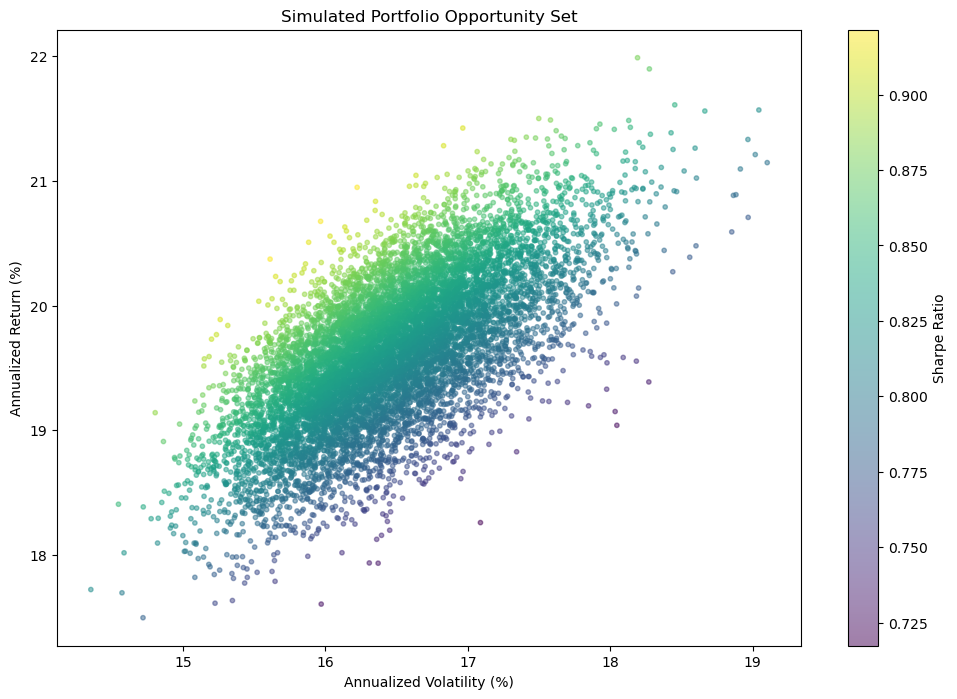

In [22]:
plt.figure(figsize=(12, 8))

plt.scatter(
    results_df["Volatility"] * 100,
    results_df["Return"] * 100,
    c=results_df["Sharpe"],
    cmap="viridis",
    alpha=0.5,
    s=10
)

plt.xlabel("Annualized Volatility (%)")
plt.ylabel("Annualized Return (%)")
plt.title("Simulated Portfolio Opportunity Set")

plt.colorbar(label="Sharpe Ratio")

plt.show()

### best portfolios

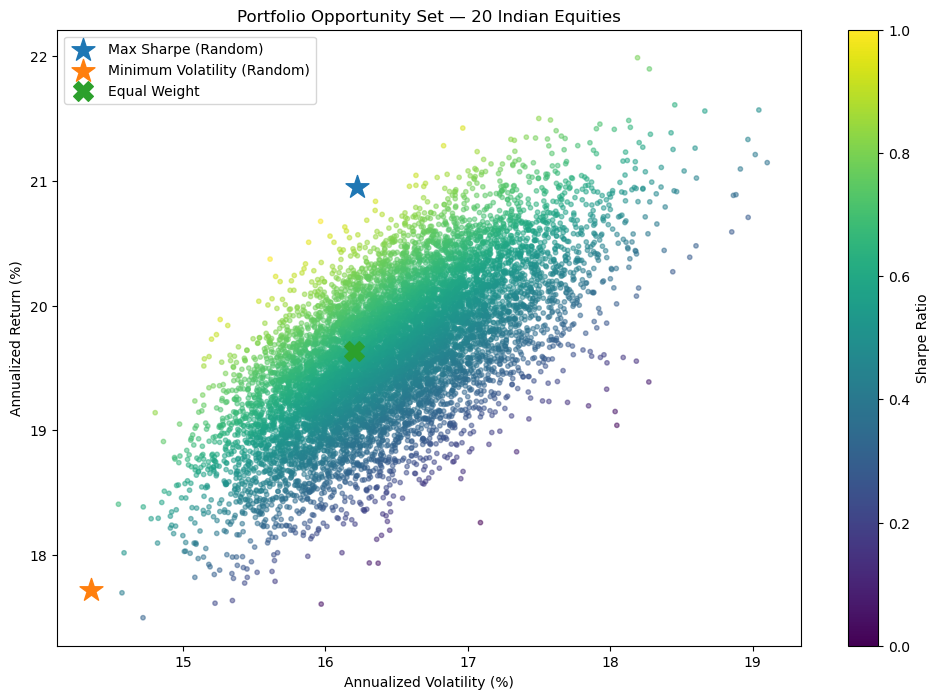

In [23]:
plt.figure(figsize=(12, 8))

plt.scatter(
    results_df["Volatility"] * 100,
    results_df["Return"] * 100,
    c=results_df["Sharpe"],
    cmap="viridis",
    alpha=0.5,
    s=10
)

# Maximum Sharpe random portfolio
plt.scatter(
    max_sharpe_random["Volatility"] * 100,
    max_sharpe_random["Return"] * 100,
    marker="*",
    s=300,
    label="Max Sharpe (Random)"
)

# Minimum volatility random portfolio
plt.scatter(
    min_volatility_random["Volatility"] * 100,
    min_volatility_random["Return"] * 100,
    marker="*",
    s=300,
    label="Minimum Volatility (Random)"
)

# Equal-weight portfolio
plt.scatter(
    ew_volatility * 100,
    ew_return * 100,
    marker="X",
    s=200,
    label="Equal Weight"
)

plt.xlabel("Annualized Volatility (%)")
plt.ylabel("Annualized Return (%)")
plt.title("Portfolio Opportunity Set — 20 Indian Equities")
plt.colorbar(label="Sharpe Ratio")
plt.legend()

plt.show()